In [1]:
from collections.abc import Iterable

import numpy as np
import pandas as pd
import qubx  # type: ignore
from qubx.core.basics import DataType
from pprint import pprint as prn

%qubxd

%load_ext autoreload
%autoreload 2

# - - - - - - - - - -
from qubx.data.transformers import PandasFrame, TypedRecords, OHLCVSeries, TickSeries, TypedGenericSeries
from qubx.data.storages.questdb import QuestDBStorage


⠀⠀⡰⡖⠒⠒⢒⢦⠀⠀   
⠀⢠⠃⠈⢆⣀⣎⣀⣱⡀  QUBX | Quantitative Backtesting Environment 
⠀⢳⠒⠒⡞⠚⡄⠀⡰⠁         (c) 2025, ver. 0.7.40.dev8
⠀⠀⠱⣜⣀⣀⣈⣦⠃⠀⠀⠀ 
        


## Reading market data

In [3]:
Q = QuestDBStorage("quantlab", synthetic_ohlc_timeframes_types=True)
r = Q.get_reader("BINANCE.UM", "SWAP")

> What symbols does storage have for ordebook data ?

In [4]:
r.get_data_id("orderbook")[:10]

['ADAUSDT',
 'BCHUSDT',
 'BNBUSDT',
 'BTCUSDT',
 'DOGEUSDT',
 'ETHUSDT',
 'LINKUSDT',
 'SOLUSDT',
 'TRXUSDT',
 'XMRUSDT']

> What data types available for symbol

In [5]:
prn(r.get_data_types("BTCUSDT"))

[orderbook,
 open_interest,
 'quotes',
 funding_payment,
 funding_rate,
 'ohlc(1min)',
 'ohlc(2min)',
 'ohlc(3min)',
 'ohlc(5min)',
 'ohlc(10min)',
 'ohlc(15min)',
 'ohlc(30min)',
 'ohlc(1h)',
 'ohlc(2h)',
 'ohlc(3h)',
 'ohlc(4h)',
 'ohlc(6h)',
 'ohlc(8h)',
 'ohlc(12h)',
 'ohlc(1d)',
 'ohlc(1w)',
 'aggregated_liquidations(1min)',
 'aggregated_liquidations(2min)',
 'aggregated_liquidations(3min)',
 'aggregated_liquidations(5min)',
 'aggregated_liquidations(10min)',
 'aggregated_liquidations(15min)',
 'aggregated_liquidations(30min)',
 'aggregated_liquidations(1h)',
 'aggregated_liquidations(2h)',
 'aggregated_liquidations(3h)',
 'aggregated_liquidations(4h)',
 'aggregated_liquidations(6h)',
 'aggregated_liquidations(8h)',
 'aggregated_liquidations(12h)',
 'aggregated_liquidations(1d)',
 'aggregated_liquidations(1w)',
 'metrics']


> Start and finish timestamps for data

In [6]:
prn(r.get_time_range("BTCUSDT", DataType.OHLC["1h"]))

(numpy.datetime64('2020-01-01T00:00:00.000000'),
 numpy.datetime64('2026-02-02T16:35:00.000000'))


> Read data for multiple symbols

In [13]:
data = r.read(["BTCUSDT", "ETHUSDT"], "ohlc(1h)", "2024-01-01", "now")

In [14]:
data

-[MULTI DATA]-
 | ETHUSDT(ohlc(1h))[2024-01-01 00:00:00 : 2026-02-02 16:00:00] : (18329 x 11)
 | BTCUSDT(ohlc(1h))[2024-01-01 00:00:00 : 2026-02-02 16:00:00] : (18329 x 11)

> Read by chunks 

In [17]:
data2 = r.read(["BTCUSDT", "ETHUSDT"], "ohlc(1h)", "2024-01-01", "now", chunksize=100)

In [18]:
assert isinstance(data2, Iterable)

for _ in range(3):
    prn(next(data2))

-[MULTI DATA]-
 | ETHUSDT(ohlc(1h))[2024-01-01 00:00:00 : 2024-01-05 03:00:00] : (100 x 11)
 | BTCUSDT(ohlc(1h))[2024-01-01 00:00:00 : 2024-01-05 03:00:00] : (100 x 11)
-[MULTI DATA]-
 | ETHUSDT(ohlc(1h))[2024-01-05 04:00:00 : 2024-01-09 07:00:00] : (100 x 11)
 | BTCUSDT(ohlc(1h))[2024-01-05 04:00:00 : 2024-01-09 07:00:00] : (100 x 11)
-[MULTI DATA]-
 | ETHUSDT(ohlc(1h))[2024-01-09 08:00:00 : 2024-01-13 11:00:00] : (100 x 11)
 | BTCUSDT(ohlc(1h))[2024-01-09 08:00:00 : 2024-01-13 11:00:00] : (100 x 11)


> Transformations

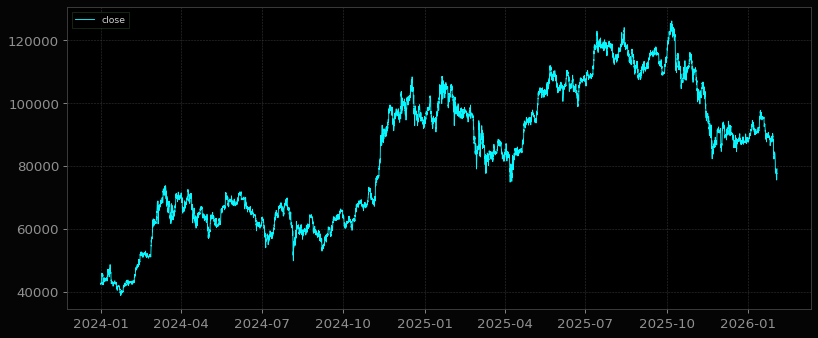

In [19]:
data.transform(OHLCVSeries())["BTCUSDT"].close.plot()

> Funding payments

In [20]:
fp = r.read(["BTCUSDT", "ETHUSDT"], DataType.FUNDING_PAYMENT, "2025-01-01", "now")
fp.transform(PandasFrame(True)).head(4)

funding_rate  funding_interval_hours
timestamp               symbol                                       
2025-01-01 00:00:00.015 BTCUSDT        0.0001                     8.0
                        ETHUSDT        0.0001                     8.0
2025-01-01 08:00:00.000 BTCUSDT        0.0001                     8.0
                        ETHUSDT        0.0001                     8.0

In [21]:
fp.transform(TypedRecords())["ETHUSDT"][:4]

[[2025-01-01T00:00:00.015000000]	 0.00010 (8.0H),
 [2025-01-01T08:00:00.000000000]	 0.00010 (8.0H),
 [2025-01-01T16:00:00.001000000]	 0.00010 (8.0H),
 [2025-01-02T00:00:00.000000000]	 0.00010 (8.0H)]

> Funding rates

In [27]:
fr = r.read(["BTCUSDT", "ETHUSDT"], DataType.FUNDING_RATE, "2026-01-01", "now")
fr.transform(PandasFrame(True)).head(4)

rate  interval   next_funding_time  \
timestamp                  symbol                                          
2026-01-01 00:00:00.000000 BTCUSDT  0.0001       8.0 2026-01-01 07:00:00   
                           ETHUSDT  0.0001       8.0 2026-01-01 07:00:00   
2026-01-01 00:00:00.014603 BTCUSDT  0.0001       8.0 2026-01-01 08:00:00   
                           ETHUSDT  0.0001       8.0 2026-01-01 08:00:00   

                                      mark_price   index_price  
timestamp                  symbol                               
2026-01-01 00:00:00.000000 BTCUSDT  87615.428638  87645.694130  
                           ETHUSDT   2970.676566   2971.851860  
2026-01-01 00:00:00.014603 BTCUSDT  87608.300000  87646.841957  
                           ETHUSDT   2970.473072   2971.618919

In [28]:
fr

-[MULTI DATA]-
 | ETHUSDT(funding_rate)[2026-01-01 00:00:00 : 2026-02-02 16:39:00] : (93145 x 7)
 | BTCUSDT(funding_rate)[2026-01-01 00:00:00 : 2026-02-02 16:39:00] : (93145 x 7)

In [51]:
fr.transform(TypedRecords())["ETHUSDT"][:4]

[[2026-01-01T00:00:00.000000000]	 0.00010 (8.0),
 [2026-01-01T00:00:00.014603000]	 0.00010 (8.0),
 [2026-01-01T00:01:00.000000000]	 0.00010 (8.0),
 [2026-01-01T00:01:00.014631000]	 0.00010 (8.0)]

> OrderBook

In [5]:
r2 = QuestDBStorage("quantlab").get_reader("HYPERLIQUID", "SWAP")

In [6]:
obd = r2.read("BTCUSDC", DataType.ORDERBOOK, "2025-09-01", "2025-09-02")

In [7]:
obd.transform(PandasFrame())

,symbol,level,price,size
timestamp,,,,
2025-09-01 00:00:00,BTCUSDC,-20,108229.0,3.03412
2025-09-01 00:00:00,BTCUSDC,-19,108230.0,2.63171
2025-09-01 00:00:00,BTCUSDC,-18,108231.0,4.19920
2025-09-01 00:00:00,BTCUSDC,-17,108232.0,0.12931
2025-09-01 00:00:00,BTCUSDC,-16,108233.0,0.11722
...,...,...,...,...
2025-09-01 23:59:00,BTCUSDC,16,109237.0,3.29309
2025-09-01 23:59:00,BTCUSDC,17,109238.0,1.46974
2025-09-01 23:59:00,BTCUSDC,18,109239.0,0.00011


In [8]:
obd.transform(TypedRecords())[:10]

[[2025-09-01T00:00:00.000000000] 108248.0 (17.674) | 108249.0 (0.61418),
 [2025-09-01T00:01:00.000000000] 108323.0 (1.92934) | 108324.0 (4.17717),
 [2025-09-01T00:02:00.000000000] 108243.0 (4.97949) | 108244.0 (8.27184),
 [2025-09-01T00:03:00.000000000] 108223.0 (1.581) | 108224.0 (23.78158),
 [2025-09-01T00:04:00.000000000] 108099.0 (0.22774) | 108100.0 (66.45798),
 [2025-09-01T00:05:00.000000000] 108056.0 (0.73386) | 108057.0 (7.89912),
 [2025-09-01T00:06:00.000000000] 108040.0 (32.41458) | 108041.0 (3e-05),
 [2025-09-01T00:07:00.000000000] 108146.0 (1.7699) | 108147.0 (7.15452),
 [2025-09-01T00:08:00.000000000] 108027.0 (4.51625) | 108028.0 (10.93856),
 [2025-09-01T00:09:00.000000000] 107984.0 (0.00011) | 107985.0 (39.44088)]

In [9]:
obd.transform(TypedGenericSeries())[:4]

[[2025-09-01T23:59:00.000000000] 109221.0 (1.80875) | 109222.0 (0.24049),
 [2025-09-01T23:58:00.000000000] 109234.0 (12.98871) | 109235.0 (0.6638),
 [2025-09-01T23:57:00.000000000] 109205.0 (8.29192) | 109206.0 (1.35073),
 [2025-09-01T23:56:00.000000000] 109142.0 (4.17757) | 109143.0 (0.04022)]

> Open Interest

In [66]:
oi = r.read(["BTCUSDT", "SOLUSDT"], DataType.OPEN_INTEREST, "2022-09-01", "2025-09-02")

In [82]:
oi.transform(PandasFrame())

SOLUSDT                                  BTCUSDT  \
                          symbol open_interest open_interest_usd   symbol   
timestamp                                                                   
2025-07-31 13:37:57.375  SOLUSDT    8853439.70      1.567501e+09  BTCUSDT   
2025-07-31 13:49:18.549  SOLUSDT    8870948.29      1.572464e+09  BTCUSDT   
2025-07-31 13:50:00.000  SOLUSDT    8871056.17      1.573104e+09  BTCUSDT   
2025-07-31 13:55:00.000  SOLUSDT    8873203.59      1.577123e+09  BTCUSDT   
2025-07-31 14:00:00.000  SOLUSDT    8887525.07      1.579669e+09  BTCUSDT   
...                          ...           ...               ...      ...   
2025-09-01 23:35:00.000  SOLUSDT   10787665.30      2.110607e+09  BTCUSDT   
2025-09-01 23:40:00.000  SOLUSDT   10793490.11      2.118654e+09  BTCUSDT   
2025-09-01 23:45:00.000  SOLUSDT   10791094.69      2.124659e+09  BTCUSDT   
2025-09-01 23:50:00.000  SOLUSDT   10775525.96      2.119869e+09  BTCUSDT   
2025-09-01 23:55:00.000  SOLUSDT   10776517.06      2.121788e+09  BTCUSDT   

                                                         
                        open_interest open_interest_usd  
timestamp                                                
2025-07-31 13:37:57.375     91216.329      1.076755e+10  
2025-07-31 13:49:18.549     91168.941      1.079021e+10  
2025-07-31 13:50:00.000     91246.142      1.080582e+10  
2025-07-31 13:55:00.000     91354.336      1.083505e+10  
2025-07-31 14:00:00.000     91427.846      1.084151e+10  
...                               ...               ...  
2025-09-01 23:35:00.000     88200.487      9.587172e+09  
2025-09-01 23:40:00.000     88327.989      9.619457e+09  
2025-09-01 23:45:00.000     88456.788      9.648858e+09  
2025-09-01 23:50:00.000     88349.353      9.642139e+09  
2025-09-01 23:55:00.000     88388.794      9.644773e+09  

[7265 rows x 6 columns]

In [83]:
oi.transform(TypedRecords()) #["SOLUSDT"][:10]

{'SOLUSDT': [[2025-07-31T13:37:57.375000000]	 SOLUSDT | 8853439.70 (1567501498.8850),
  [2025-07-31T13:49:18.549000000]	 SOLUSDT | 8870948.29 (1572464293.8854),
  [2025-07-31T13:50:00.000000000]	 SOLUSDT | 8871056.17 (1573104390.6261),
  [2025-07-31T13:55:00.000000000]	 SOLUSDT | 8873203.59 (1577123206.0866),
  [2025-07-31T14:00:00.000000000]	 SOLUSDT | 8887525.07 (1579668705.9418),
  [2025-07-31T14:05:00.000000000]	 SOLUSDT | 8900828.64 (1580253116.7456),
  [2025-07-31T14:10:00.000000000]	 SOLUSDT | 8905530.53 (1578683397.0531),
  [2025-07-31T14:15:00.000000000]	 SOLUSDT | 8929711.10 (1581541132.9210),
  [2025-07-31T14:20:00.000000000]	 SOLUSDT | 8935668.21 (1576966725.7008),
  [2025-07-31T14:25:00.000000000]	 SOLUSDT | 8948205.08 (1575778914.5880),
  [2025-07-31T14:30:00.000000000]	 SOLUSDT | 8959578.43 (1576437824.7585),
  [2025-07-31T14:35:00.000000000]	 SOLUSDT | 8959167.86 (1581203535.6114),
  [2025-07-31T14:40:00.000000000]	 SOLUSDT | 8963254.49 (1580759561.8564),
  [2025-07-31T

> Liquidations

It supports aggregated liquidations now

In [84]:
liq1m = r.read("BTCUSDT", DataType.AGGREGATED_LIQUIDATIONS["1min"], "2025-01-01", "2025-09-02")
liq1H = r.read("BTCUSDT", DataType.AGGREGATED_LIQUIDATIONS["1h"], "2025-01-01", "2025-09-02")

In [85]:
liq1m.transform(TypedRecords())[:10]

[[2025-01-01T00:19:00.000000000]	 B:0.02 @ 94178.995 | S:nan @ nan,
 [2025-01-01T00:20:00.000000000]	 B:0.006 @ 94200.73 | S:nan @ nan,
 [2025-01-01T00:22:00.000000000]	 B:0.002 @ 94207.98 | S:nan @ nan,
 [2025-01-01T00:23:00.000000000]	 B:0.015 @ 94235.28333333333 | S:nan @ nan,
 [2025-01-01T00:34:00.000000000]	 B:0.047 @ 94288.44 | S:nan @ nan,
 [2025-01-01T00:50:00.000000000]	 B:0.009 @ 94326.73 | S:nan @ nan,
 [2025-01-01T00:51:00.000000000]	 B:0.002 @ 94333.21 | S:nan @ nan,
 [2025-01-01T00:52:00.000000000]	 B:0.8350000000000001 @ 94396.1325 | S:nan @ nan,
 [2025-01-01T00:53:00.000000000]	 B:0.336 @ 94479.44 | S:nan @ nan,
 [2025-01-01T00:54:00.000000000]	 B:0.403 @ 94515.29 | S:nan @ nan]

In [70]:
liq1m.transform(PandasFrame())

,symbol,avg_buy_price,buy_amount,buy_count,buy_notional,last_buy_price,avg_sell_price,sell_amount,sell_count,sell_notional,last_sell_price
timestamp,,,,,,,,,,,
2025-01-01 00:19:00,BTCUSDT,94178.995000,0.020,2,1883.75801,94188.89,NaN,NaN,0,NaN,NaN
2025-01-01 00:20:00,BTCUSDT,94200.730000,0.006,1,565.20438,94200.73,NaN,NaN,0,NaN,NaN
2025-01-01 00:22:00,BTCUSDT,94207.980000,0.002,1,188.41596,94207.98,NaN,NaN,0,NaN,NaN
2025-01-01 00:23:00,BTCUSDT,94235.283333,0.015,3,1413.56635,94244.31,NaN,NaN,0,NaN,NaN
2025-01-01 00:34:00,BTCUSDT,94288.440000,0.047,3,4432.11285,94314.57,NaN,NaN,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2025-07-06 23:27:00,BTCUSDT,0.000000,0.000,0,0.00000,0.00,108613.7,0.008,1,868.9096,108613.7
2025-07-06 23:30:00,BTCUSDT,109492.400000,0.002,1,218.98480,109492.40,0.0,0.000,0,0.0000,0.0
2025-07-06 23:31:00,BTCUSDT,109441.100000,0.001,1,109.44110,109441.10,108562.5,0.007,1,759.9375,108562.5


In [ ]:
liq1H.transform(TypedRecords())[:10]

[[2025-01-01T01:00:00.000000000]	 B:2.048 @ 94408.38601190476 | S:nan @ nan,
 [2025-01-01T02:00:00.000000000]	 B:0.04 @ 10536.533333333333 | S:1.4000000000000001 @ 93371.7765340909,
 [2025-01-01T03:00:00.000000000]	 B:0.193 @ 70762.18928571428 | S:0.003 @ 23320.61,
 [2025-01-01T04:00:00.000000000]	 B:0.0 @ 0.0 | S:0.060000000000000005 @ 93430.46333333332,
 [2025-01-01T05:00:00.000000000]	 B:0.052 @ 15683.25 | S:0.128 @ 77739.06666666667,
 [2025-01-01T06:00:00.000000000]	 B:0.021 @ 23567.9775 | S:0.14500000000000002 @ 69967.1225,
 [2025-01-01T07:00:00.000000000]	 B:0.0 @ 0.0 | S:0.011 @ 93311.45999999999,
 [2025-01-01T09:00:00.000000000]	 B:0.014 @ 28190.314000000002 | S:1.814 @ 65116.331847222216,
 [2025-01-01T10:00:00.000000000]	 B:0.333 @ 22489.2252 | S:2.349 @ 85374.6423220779,
 [2025-01-01T11:00:00.000000000]	 B:0.36 @ 93838.02875 | S:0.0 @ 0.0]

In [74]:
liq1H.transform(PandasFrame())

,symbol,avg_buy_price,buy_amount,buy_count,buy_notional,last_buy_price,avg_sell_price,sell_amount,sell_count,sell_notional,last_sell_price
timestamp,,,,,,,,,,,
2025-01-01 01:00:00,BTCUSDT,94408.386012,2.048,37,1.934723e+05,94822.84,NaN,NaN,0,NaN,NaN
2025-01-01 02:00:00,BTCUSDT,10536.533333,0.040,1,3.793152e+03,0.00,93371.776534,1.400,24,130606.07290,93223.32
2025-01-01 03:00:00,BTCUSDT,70762.189286,0.193,9,1.821271e+04,94457.90,23320.610000,0.003,1,279.84732,0.00
2025-01-01 04:00:00,BTCUSDT,0.000000,0.000,0,0.000000e+00,0.00,93430.463333,0.060,3,5607.79214,93330.04
2025-01-01 05:00:00,BTCUSDT,15683.250000,0.052,1,4.893174e+03,0.00,77739.066667,0.128,7,11934.53541,93215.51
...,...,...,...,...,...,...,...,...,...,...,...
2025-07-06 20:00:00,BTCUSDT,81673.725000,0.043,3,4.683088e+03,0.00,26962.350000,0.002,1,215.69880,107849.40
2025-07-06 21:00:00,BTCUSDT,81869.093194,1.245,23,1.358918e+05,109079.90,27059.491667,0.063,3,6818.10000,0.00
2025-07-06 22:00:00,BTCUSDT,89314.518337,13.475,117,1.480768e+06,109535.90,32231.511543,0.502,14,54625.92277,0.00


> Fundamental

In [75]:
Q.get_market_types("COINGECKO")

['FUNDAMENTAL']

In [76]:
fu = Q.get_reader("COINGECKO", "FUNDAMENTAL")

In [77]:
fu.get_data_id()[:10]

['0G',
 '1',
 '1000000BABYDOGE',
 '1000000BOB',
 '1000000CHEEMS',
 '1000000MOG',
 '1000000PEIPEI',
 '1000000VINU',
 '10000COQ',
 '10000ELON']

In [78]:
fd = fu.read(fu.get_data_id(), "fundamental", "2020-01-01", "now")

In [79]:
fd.transform(PandasFrame(True))

asset        metric         value
timestamp  symbol                                        
2020-01-01 1000LUNC  1000LUNC    market_cap  4.836180e+07
           1000LUNC  1000LUNC         price  2.582946e-01
           1000LUNC  1000LUNC  total_volume  4.349296e+06
           ADA            ADA  total_volume  7.808976e+07
           ADA            ADA         price  3.291193e-02
...                       ...           ...           ...
2026-02-02 老子              老子    market_cap  1.573467e+06
           老子              老子         price  1.573058e-03
           雪球              雪球         price  2.011281e-02
           雪球              雪球    market_cap  4.921838e+06
           雪球              雪球  total_volume  5.275406e+06

[3727203 rows x 3 columns]

## Reading external data 

In [86]:
from qubx.data.registry import StorageRegistry

In [87]:
Q = StorageRegistry.get("qdb::quantlab")

In [88]:
Q.get_market_types("UNRAVEL")

['FACTORS', 'UNIVERSE']

In [89]:
ur = Q.get_reader("UNRAVEL", "FACTORS")
uv = Q.get_reader("UNRAVEL", "UNIVERSE")

In [90]:
ur.read("BTCUSDT", "FACTORS", "2020-01-01", "now").transform(PandasFrame())

,factor,symbol,value
timestamp,,,
2020-01-01,momentum_enhanced,BTCUSDT,-0.245386
2020-01-02,momentum_enhanced,BTCUSDT,-0.363726
2020-01-03,momentum_enhanced,BTCUSDT,-0.082397
2020-01-04,momentum_enhanced,BTCUSDT,-0.034289
2020-01-05,momentum_enhanced,BTCUSDT,-0.023747
...,...,...,...
2025-08-07,retail_flow,BTCUSDT,-0.990036
2025-08-08,carry_enhanced,BTCUSDT,-0.006198
2025-08-08,momentum_enhanced,BTCUSDT,0.671556


In [91]:
uv.read("BTCUSDT", "UNIVERSE", "2020-01-01", "now").transform(PandasFrame())

,symbol,value
timestamp,,
2020-01-01,BTCUSDT,True
2020-01-02,BTCUSDT,True
2020-01-03,BTCUSDT,True
2020-01-04,BTCUSDT,True
2020-01-05,BTCUSDT,True
...,...,...
2025-08-04,BTCUSDT,True
2025-08-05,BTCUSDT,True
2025-08-06,BTCUSDT,True


## Custom SQL builders (experimental)

In [92]:
Q = QuestDBStorage("quantlab")

In [93]:
def _Only_RetailFactor(symbols: set[str], conditions: list[str], resample: str) -> str:
    conditions.append("factor = 'retail_flow'")
    return """SELECT timestamp, symbol, value FROM "{table}" {where};"""

ur.add_external_builder("FACTORS", _Only_RetailFactor)
ur.read("BTCUSDT", "FACTORS", "2020-01-01", "now").transform(PandasFrame())

,symbol,value
timestamp,,
2020-11-15,BTCUSDT,-3.089376
2020-11-16,BTCUSDT,-2.601349
2020-11-17,BTCUSDT,-1.886458
2020-11-18,BTCUSDT,-1.657699
2020-11-19,BTCUSDT,-1.820243
...,...,...
2025-08-04,BTCUSDT,-0.660357
2025-08-05,BTCUSDT,-0.735399
2025-08-06,BTCUSDT,-0.902107


## Orderbook reading with parametrization

In [95]:
from qubx.core.series import OrderBook
from qubx.utils.questdb import QuestDBClient

from qubx.data.storages.utils import find_column_index_in_list

Insert test data into DB

In [3]:
if 0:
    c = QuestDBClient("nebula")
    f = []
    p0 = 100
    for k, t in enumerate(pd.date_range("2020-01-02 00:00:00", None, 10000, "1min")):
        for l in range(-200, 200): # 200 levels for each side
            if l == 0:
                continue
            f.append({ "timestamp": t, "symbol": "BTCUSDT", "level": l, 
                      "price": p0 + k / 10 + l/10, "size": (k + abs(l)) * 10 })
    c.insert_dataframe(pd.DataFrame(f), "binance.umswap.orderbook_1m")
    # del f

In [9]:
Q = QuestDBStorage("nebula")
r = Q.get_reader("BINANCE.UM", "SWAP")

In [10]:
r.get_data_types("BTCUSDT")

[open_interest,
 funding_payment,
 orderbook,
 'ohlc(1min)',
 'ohlc(2min)',
 'ohlc(3min)',
 'ohlc(5min)',
 'ohlc(10min)',
 'ohlc(15min)',
 'ohlc(30min)',
 'ohlc(1h)',
 'ohlc(2h)',
 'ohlc(3h)',
 'ohlc(4h)',
 'ohlc(6h)',
 'ohlc(8h)',
 'ohlc(12h)',
 'ohlc(1d)',
 'ohlc(1w)']

In [11]:
%%time
ob = r.read("BTCUSDT", DataType.ORDERBOOK[0, 200], "2020-01-01", "2020-01-10")

CPU times: user 8.22 s, sys: 771 ms, total: 8.99 s
Wall time: 11.1 s


In [8]:
%%time
ob.transform(PandasFrame())

CPU times: user 143 ms, sys: 71.1 ms, total: 214 ms
Wall time: 108 ms


,symbol,level,price,size
timestamp,,,,
2020-01-01 00:00:00,BTCUSDT,-200,80.0,2000.0
2020-01-01 00:00:00,BTCUSDT,-199,80.1,1990.0
2020-01-01 00:00:00,BTCUSDT,-198,80.2,1980.0
2020-01-01 00:00:00,BTCUSDT,-197,80.3,1970.0
2020-01-01 00:00:00,BTCUSDT,-196,80.4,1960.0
...,...,...,...,...
2020-01-08 22:39:00,BTCUSDT,195,1119.4,101940.0
2020-01-08 22:39:00,BTCUSDT,196,1119.5,101950.0
2020-01-08 22:39:00,BTCUSDT,197,1119.6,101960.0


In [12]:
%%time
ob = r.read("BTCUSDT", DataType.ORDERBOOK[0, 200], "2020-01-01", "2020-01-10")

CPU times: user 9.68 s, sys: 1.17 s, total: 10.8 s
Wall time: 12.6 s


In [13]:
%%time
ob.transform(PandasFrame())

CPU times: user 125 ms, sys: 80.4 ms, total: 205 ms
Wall time: 131 ms


,symbol,level,price,size
timestamp,,,,
2020-01-01 00:00:00,BTCUSDT,-200,80.0,2000.0
2020-01-01 00:00:00,BTCUSDT,-199,80.1,1990.0
2020-01-01 00:00:00,BTCUSDT,-198,80.2,1980.0
2020-01-01 00:00:00,BTCUSDT,-197,80.3,1970.0
2020-01-01 00:00:00,BTCUSDT,-196,80.4,1960.0
...,...,...,...,...
2020-01-08 22:39:00,BTCUSDT,195,1119.4,101940.0
2020-01-08 22:39:00,BTCUSDT,196,1119.5,101950.0
2020-01-08 22:39:00,BTCUSDT,197,1119.6,101960.0


In [137]:
%%time
len(ob.transform(TypedRecords()))

CPU times: user 586 ms, sys: 20.8 ms, total: 607 ms
Wall time: 580 ms


10099

### experiments with cython

In [31]:
%load_ext cython

In [ ]:
%%cython -a 
import numpy as np
# cimport numpy as np
from qubx.core.series import OrderBook

def build_snapshots(raw: list[tuple], max_levels: int, L: int, P: int, S: int, T: int):
    cdef int l
    cdef long long ti, t_process
    cdef double ask, bid
    cdef list collected

    ask, bid = np.nan, np.nan
    t_process = int(raw[0][T].timestamp() * 1000000000)

    asks = np.zeros(max_levels)
    bids = np.zeros(max_levels)
    collected = []

    for xr in raw:
        ti = int(xr[T].timestamp() * 1000000000)
        l = xr[L]
        
        if l > 0:
            asks[l-1] = xr[S]
            if l == 1:
                ask = xr[P]
        else:
            bids[(-l)-1] = xr[S]
            if l == -1:
                bid = xr[P]

        if ti > t_process:
            collected.append(OrderBook(ti, bid, ask, ask - bid, bids.copy(), asks.copy()))
            asks.fill(0)
            bids.fill(0)
            t_process = ti
    return collected 

In [41]:
L = find_column_index_in_list(ob.names, "level")
P = find_column_index_in_list(ob.names, "price")
S = find_column_index_in_list(ob.names, "size")
T = find_column_index_in_list(ob.names, "timestamp", "time")
t_process = ob.raw[0][T]
max_levels = 0
for xr in ob.raw:
    max_levels = max(abs(xr[L]), max_levels)
    if xr[T] > t_process:
        break

In [42]:
%%time
xs = build_snapshots(ob.raw, max_levels, L, P, S, T)
print("Input records - ", len(ob.raw), "output snapshots - ", len(xs))

Input records -  4029900 output snapshots -  10099
CPU times: user 1.33 s, sys: 57 ms, total: 1.39 s
Wall time: 1.35 s


In [102]:
def py_build_snapshots(raw: list[tuple], L: int, P: int, S: int, T: int):
    t_process = raw[0][T]

    # - find max levels
    max_levels = 0
    for xr in raw:
        max_levels = max(abs(xr[L]), max_levels)
        if xr[T] > t_process:
            break

    asks = np.zeros(max_levels)
    bids = np.zeros(max_levels)
    ask, bid = np.nan, np.nan

    collected = []
    for xr in raw:
        ti = xr[T]
        l = xr[L]
        if l > 0:
            asks[l-1] = xr[S]
            if l == 1:
                ask = xr[P]
        else:
            bids[(-l)-1] = xr[S]
            if l == -1:
                bid = xr[P]
        if ti > t_process:
            collected.append(OrderBook(np.datetime64(ti, "ns").item(), bid, ask, ask - bid, bids.copy(), asks.copy()))
            asks = np.zeros(max_levels)
            bids = np.zeros(max_levels)
            t_process = ti
    return collected

In [124]:
L = find_column_index_in_list(ob.names, "level")
P = find_column_index_in_list(ob.names, "price")
S = find_column_index_in_list(ob.names, "size")
T = find_column_index_in_list(ob.names, "timestamp", "time")

In [125]:
%%time
xs1 = py_build_snapshots(ob.raw, L, P, S, T)
print("Input records - ", len(ob.raw), "output snapshots - ", len(xs1))

Input records -  20200 output snapshots -  10099
CPU times: user 36.3 ms, sys: 4 μs, total: 36.3 ms
Wall time: 35.4 ms


In [105]:
for i in range(len(xs)):
    assert all((
        xs[i].time == xs1[i].time,
        xs[i].tick_size == xs1[i].tick_size,
        xs[i].top_ask == xs1[i].top_ask,
        xs[i].top_bid == xs1[i].top_bid,
        all(xs[i].bids == xs1[i].bids),
        all(xs[i].asks == xs1[i].asks),
    ))